# Training TBModel on Auditory Cortex Data

# 1. Graph-level Classification

This notebook demonstrates three different tasks using the A123 mouse auditory cortex dataset:

1. **Graph-level Classification**: Predict frequency bin (0-8) from graph structure
2. **Triangle Classification**: Classify topological role of triangles in the correlation graph
3. **Triangle Common-Neighbors**: Predict the number of common neighbors for triangles

We'll show how to load the dataset, apply lifting transformations, define a backbone, and train a `TBModel` using `TBLoss` and `TBOptimizer`.

Requirements: the project installed in PYTHONPATH and optional dependencies (torch_geometric, networkx, ripser/persim) if you want advanced features.

**Task 1: Graph-level Classification**
- Input: Graph structure with node features (mean correlation, std correlation, noise diagonal)
- Output: Frequency bin (0-8) representing the best frequency
- Level: Graph-level prediction

In [18]:
from pathlib import Path
import os


def _find_repo_root(start: Path) -> Path | None:
    for p in [start, *start.parents]:
        # Repo root has both package and tutorials folder
        if (p / "topobench").exists() and (p / "tutorials").exists():
            return p
    return None


# Prefer explicit workspace path, then fall back to cwd walk-up.
candidates = [
    Path("/Users/greciacastelazo/topobench"),
    Path.cwd(),
]

REPO_ROOT = None
for c in candidates:
    if c.exists() and (c / "topobench").exists() and (c / "tutorials").exists():
        REPO_ROOT = c
        break
    found = _find_repo_root(c)
    if found is not None:
        REPO_ROOT = found
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root. Set REPO_ROOT manually.")

os.chdir(REPO_ROOT)
print(f"Working directory set to: {REPO_ROOT}")

Working directory set to: /Users/greciacastelazo/topobench


In [19]:
# 1) Imports
import torch
import numpy as np
import lightning as pl
from omegaconf import OmegaConf

# Data loading / preprocessing utilities from the repo
from topobench.data.loaders.graph.a123_loader import A123DatasetLoader
from topobench.dataloader.dataloader import TBDataloader
from topobench.data.preprocessor import PreProcessor

# Model / training building blocks
from topobench.model.model import TBModel
# example backbone building block (SCN2 is optional; we provide a tiny custom backbone below)
# from topomodelx.nn.simplicial.scn2 import SCN2
from topobench.nn.wrappers.simplicial import SCNWrapper
from topobench.nn.encoders import AllCellFeatureEncoder
from topobench.nn.readouts import PropagateSignalDown

# Optimization / evaluation
from topobench.loss.loss import TBLoss
from topobench.optimizer import TBOptimizer
from topobench.evaluator.evaluator import TBEvaluator

print('Imports OK')

Imports OK


In [20]:
from pathlib import Path
import os

p = Path("/Users/greciacastelazo/topobench/data/a123_cortex_m/processed").resolve()
print("Path:", p)
print("Exists:", p.exists())
print("Writable dir:", os.access(p.parent, os.W_OK))
if p.exists():
    for f in p.glob("*"):
        print(f.name, "writable:", os.access(f, os.W_OK))

Path: /Users/greciacastelazo/topobench/data/a123_cortex_m/processed
Exists: True
Writable dir: True
pre_transform.pt writable: True
pre_filter.pt writable: True
data.pt writable: True


In [22]:
# Task configurations
tasks = {
    'graph_classification': {
        'description': 'Graph-level classification (predict frequency bin 0-8)',
        'specific_task': 'classification',
        'in_channels': 3,
        'out_channels': 9,
        'task_level': 'graph',
    },
    'triangle_classification': {
        'description': 'Triangle classification (predict topological role, 9 classes)',
        'specific_task': 'triangle_classification',
        'in_channels': 3,
        'out_channels': 9,
        'task_level': 'graph',
    },
    'triangle_common_neighbors': {
        'description': 'Triangle common-neighbors (predict # common neighbors, 9 classes)',
        'specific_task': 'triangle_common_neighbors',
        'in_channels': 3,
        'out_channels': 9,
        'task_level': 'graph',
    }
}

In [23]:
# Select task to run (change to 'graph_classification', 'triangle_classification' or 'triangle_common_neighbors' to run different tasks)
TASK_NAME = 'graph_classification'
TASK_CONFIG = tasks[TASK_NAME]

print(f"Selected task: {TASK_NAME}")
print(f"Description: {TASK_CONFIG['description']}")


Selected task: graph_classification
Description: Graph-level classification (predict frequency bin 0-8)


In [24]:
# 2) Configurations for different tasks
# Note: We'll demonstrate each task separately by changing the specific_task parameter

# Common loader config
loader_config_base = {
    'data_domain': 'graph',
    'data_type': 'A123',
    'data_name': 'a123_cortex_m',
    'data_dir': str(REPO_ROOT / 'data' / 'a123'),
    'corr_threshold': 0.3,  # Higher threshold ensures graphs have meaningful edges
}

# Transform config: using CellCycleLifting (more robust for graphs with few edges)
# CellCycleLifting finds cycles and lifts them to 2-cells, handles empty graphs gracefully
transform_config = {
    'transform_type': 'lifting',
    'transform_name': 'SimplicialGraphInducedLifting', # SimplicialGraphInducedLifting, CellCycleLifting
    'max_cell_length': None,  # No limit on cycle length
}

split_dir = REPO_ROOT / 'data' / 'a123' / 'splits' / TASK_CONFIG['specific_task']
os.makedirs(split_dir, exist_ok=True)

split_config = {
    'learning_setting': 'inductive',
    'split_type': 'random',
    'data_seed': 0,
    'data_split_dir': str(split_dir),
    'train_prop': 0.4,
}

In [25]:
# Create loader config with specific task
loader_config = OmegaConf.create({**loader_config_base, 'specific_task': TASK_CONFIG['specific_task']})

dim_hidden = 16
in_channels = TASK_CONFIG['in_channels']
out_channels = TASK_CONFIG['out_channels']

readout_config = {
    'readout_name': 'PropagateSignalDown',
    'num_cell_dimensions': 1,
    'hidden_dim': dim_hidden,
    'out_channels': out_channels,
    'task_level': TASK_CONFIG['task_level'],
    'pooling_type': 'sum',
}

loss_config = {
    'dataset_loss': {
        'task': 'classification',
        'loss_type': 'cross_entropy',
    }
}

evaluator_config = {
    'task': 'classification',
    'num_classes': out_channels,
    'metrics': ['f1', 'precision', 'recall', 'accuracy'],
}

optimizer_config = {
    'optimizer_id': 'Adam',
    'parameters': {'lr': 0.001, 'weight_decay': 0.0005},
}

# Convert to OmegaConf
transform_config = OmegaConf.create(transform_config)
split_config = OmegaConf.create(split_config)
readout_config = OmegaConf.create(readout_config)
loss_config = OmegaConf.create(loss_config)
evaluator_config = OmegaConf.create(evaluator_config)
optimizer_config = OmegaConf.create(optimizer_config)

print('Configs created')
print(f"Loader config: {loader_config}")
print(f"Input channels: {in_channels}, Output channels: {out_channels}")

Configs created
Loader config: {'data_domain': 'graph', 'data_type': 'A123', 'data_name': 'a123_cortex_m', 'data_dir': '/Users/greciacastelazo/topobench/data/a123', 'corr_threshold': 0.3, 'specific_task': 'classification'}
Input channels: 3, Output channels: 9


In [26]:
from pathlib import Path
import shutil
from topobench.data.loaders.graph.a123_loader import A123DatasetLoader

# make sure task is set BEFORE loader init
print("specific_task:", loader_config.specific_task)

graph_loader = A123DatasetLoader(loader_config)

root_parent = graph_loader.root_data_dir.parent
dataset_name = loader_config.data_name
processed_dir = Path(root_parent) / dataset_name / "processed"
raw_dir = Path(root_parent) / dataset_name / "raw"

tri_file = processed_dir / "data_triangles.pt"
tri_cn_file = processed_dir / "data_triangles_common_neighbors.pt"
base_file = processed_dir / "data.pt"

print("cwd:", Path.cwd())
print("root_data_dir:", graph_loader.root_data_dir)
print("root_parent:", root_parent)
print("raw_dir:", raw_dir)
print("processed_dir:", processed_dir)
print("exists data.pt:", base_file.exists())
print("exists data_triangles.pt:", tri_file.exists())
print("exists data_triangles_common_neighbors.pt:", tri_cn_file.exists())

# Force regenerate ONLY processed artifacts (keep raw, avoid re-download)
if processed_dir.exists():
    shutil.rmtree(processed_dir)
    print("Deleted:", processed_dir)

dataset, dataset_dir = graph_loader.load()
print("Reloaded. dataset_dir:", dataset_dir)
print("Now exists data.pt:", base_file.exists())
print("Now exists data_triangles.pt:", tri_file.exists())
print("Now exists data_triangles_common_neighbors.pt:", tri_cn_file.exists())

specific_task: classification
cwd: /Users/greciacastelazo/topobench
root_data_dir: /Users/greciacastelazo/topobench/data/a123
root_parent: /Users/greciacastelazo/topobench/data
raw_dir: /Users/greciacastelazo/topobench/data/a123_cortex_m/raw
processed_dir: /Users/greciacastelazo/topobench/data/a123_cortex_m/processed
exists data.pt: True
exists data_triangles.pt: False
exists data_triangles_common_neighbors.pt: False
Deleted: /Users/greciacastelazo/topobench/data/a123_cortex_m/processed
[A123] Processing dataset from: /Users/greciacastelazo/topobench/data/a123_cortex_m/raw
[A123] Files in raw_dir: ['.DS_Store', 'Auditory cortex data', '__MACOSX']
[A123] Starting extract_samples()...
Processing session 0: allPlanesVariables27-Feb-2021.mat


Processing...


Processing session 1: allPlanesVariables27-Feb-2021.mat
Processing session 2: allPlanesVariables27-Feb-2021.mat
Processing session 3: allPlanesVariables27-Feb-2021.mat
Processing session 4: allPlanesVariables27-Feb-2021.mat
Processing session 5: allPlanesVariables27-Feb-2021.mat
Processing session 6: allPlanesVariables27-Feb-2021.mat
Processing session 7: allPlanesVariables27-Feb-2021.mat
[A123] Extracted 250 samples
[A123] Converting sample 0/250 to PyG Data...
[A123] Converting sample 100/250 to PyG Data...
[A123] Converting sample 200/250 to PyG Data...
[A123] Collating 250 samples (removed 0 empty graphs)...
[A123] Saving processed data to /Users/greciacastelazo/topobench/data/a123_cortex_m/processed/data.pt...
[A123] Processing complete!
Reloaded. dataset_dir: /Users/greciacastelazo/topobench/data/a123/a123_cortex_m
Now exists data.pt: True
Now exists data_triangles.pt: False
Now exists data_triangles_common_neighbors.pt: False


Done!


In [10]:
# 3) Loading the data
import shutil
from pathlib import Path

graph_loader = A123DatasetLoader(loader_config)
dataset, dataset_dir = graph_loader.load()
print(f'Dataset loaded: {len(dataset)} samples')

Dataset loaded: 250 samples


In [27]:
data_123 = torch.load("/Users/greciacastelazo/topobench/data/a123_cortex_m/processed/data.pt")

print(data_123[0].keys())

for key in data_123[0].keys():
    print(f"{key} : {data_123[0][key].shape}")

dict_keys(['x', 'edge_index', 'edge_attr', 'y', 'session_id', 'layer'])
x : torch.Size([5912, 3])
edge_index : torch.Size([2, 91922])
edge_attr : torch.Size([91922, 1])
y : torch.Size([250])
session_id : torch.Size([250])
layer : torch.Size([250])


## Summary of dataset 

Total of 250 samples acquired across the 5 layers --> $y$ labels

Total nodes recorded ---> 5912

Total edges recorded --> 91922

Batch size --> 32. How does the batching work? how many graphs were generated?

In [38]:
print(dataset.data.keys())
print(dataset.slices.keys())

for key in dataset.data.keys():
    print(f"{key} : {dataset.data[key].shape}")

['x', 'y', 'edge_attr', 'session_id', 'layer', 'edge_index']
dict_keys(['x', 'edge_index', 'edge_attr', 'y', 'session_id', 'layer'])
x : torch.Size([5912, 3])
y : torch.Size([250])
edge_attr : torch.Size([91922, 1])
session_id : torch.Size([250])
layer : torch.Size([250])
edge_index : torch.Size([2, 91922])


/var/folders/19/9b_f9f4535n0sd41pxpp1grm0000gn/T/ipykernel_52128/2372313549.py:1: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  print(dataset.data.keys())
/var/folders/19/9b_f9f4535n0sd41pxpp1grm0000gn/T/ipykernel_52128/2372313549.py:4: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  for key in dataset.data.keys():
/var/folders/19/9b_f9f4535n0sd41pxpp1grm0000gn/T/ipykernel_52

In [67]:
x_tensor_indx = dataset.slices["x"]
#print(x_tensor_indx[1:] - x_tensor_indx[:-1])

In [28]:
data_123[0]["layer"]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3,
        4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1, 1, 1,
        2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4,
        5, 5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3,
        3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5,
        5, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5,
        5, 5, 5, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3,
        4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3,
        3, 4, 4, 4, 4, 5, 5, 5, 5, 5])

In [74]:
task_type = TASK_CONFIG['specific_task']

preprocessor = PreProcessor(dataset, dataset_dir, transforms_config=None)

# Recreate split files for this task to avoid stale-index mismatches
split_seed_dir = Path(split_config.data_split_dir) / f"train_prop={split_config.train_prop}_global_seed=42"
if split_seed_dir.exists():
    shutil.rmtree(split_seed_dir)
    print(f"Deleted stale split directory: {split_seed_dir}")

dataset_train, dataset_val, dataset_test = preprocessor.load_dataset_splits(split_config)
print('Dataset splits created:')
print(f'  Train: {len(dataset_train)} samples')
print(f'  Val: {len(dataset_val)} samples')
print(f'  Test: {len(dataset_test)} samples')

# create the TopoBench datamodule / dataloader wrappers
datamodule = TBDataloader(dataset_train, dataset_val, dataset_test, batch_size=64)
print('Datasets and datamodule ready')

Deleted stale split directory: /Users/greciacastelazo/topobench/data/a123/splits/classification/train_prop=0.4_global_seed=42
Dataset splits created:
  Train: 100 samples
  Val: 75 samples
  Test: 75 samples
Datasets and datamodule ready


In [75]:
import torch

def summarize_split(name, ds, n_check=200):
    print(f"\n{name}: n_samples={len(ds)}")
    d0 = ds.data_lst[0]
    print("keys:", list(d0.keys()))

    # show first sample shapes/types
    for k in d0.keys():
        v = d0[k]
        shape = tuple(v.shape) if hasattr(v, "shape") else None
        dtype = str(v.dtype) if hasattr(v, "dtype") else type(v).__name__
        print(f"  {k:12s} shape={shape} dtype={dtype}")

    # check whether tensor shapes vary across samples
    shape_ranges = {}
    m = min(n_check, len(ds))
    for i in range(m):
        d = ds.data_lst[i]
        for k in d.keys():
            v = d[k]
            if hasattr(v, "shape"):
                shape_ranges.setdefault(k, set()).add(tuple(v.shape))
    print("shape variability (first", m, "samples):")
    for k, s in shape_ranges.items():
        print(f"  {k:12s} unique_shapes={sorted(s)}")

for split_name, ds in [("train", dataset_train), ("val", dataset_val), ("test", dataset_test)]:
    summarize_split(split_name, ds)


train: n_samples=100
keys: ['x', 'y', 'edge_attr', 'train_mask', 'session_id', 'layer', 'val_mask', 'test_mask', 'edge_index']
  x            shape=(15, 3) dtype=torch.float32
  y            shape=(1,) dtype=torch.int64
  edge_attr    shape=(76, 1) dtype=torch.float32
  train_mask   shape=(1,) dtype=torch.int64
  session_id   shape=(1,) dtype=torch.int64
  layer        shape=(1,) dtype=torch.int64
  val_mask     shape=(1,) dtype=torch.int64
  test_mask    shape=(1,) dtype=torch.int64
  edge_index   shape=(2, 76) dtype=torch.int64
shape variability (first 100 samples):
  x            unique_shapes=[(8, 3), (9, 3), (10, 3), (11, 3), (12, 3), (13, 3), (14, 3), (15, 3), (16, 3), (17, 3), (18, 3), (19, 3), (20, 3), (21, 3), (22, 3), (23, 3), (25, 3), (26, 3), (27, 3), (28, 3), (29, 3), (30, 3), (31, 3), (32, 3), (34, 3), (35, 3), (38, 3), (40, 3), (41, 3), (42, 3), (45, 3), (54, 3), (55, 3), (57, 3), (60, 3), (64, 3), (73, 3), (80, 3), (114, 3)]
  y            unique_shapes=[(1,)]
  edge_a

In [20]:
def undersample_majority_class(dataset, target_samples_per_class=100, random_state=42):
    """
    Undersample all classes to a target number of samples per class.
    
    Parameters
    ----------
    dataset : DataloadDataset
        Dataset to undersample
    target_samples_per_class : int
        Target number of samples per class (default: 100)
    random_state : int
        Random seed for reproducibility
        
    Returns
    -------
    DataloadDataset
        Undersampled dataset
    """
    np.random.seed(random_state)
    
    # Handle DataloadDataset which returns (values, keys) tuples
    labels = []
    for item in dataset:
        # The dataset returns (values_list, keys_list)
        if isinstance(item, (list, tuple)) and len(item) == 2:
            values, keys = item
            # The 'y' label is the last value in the list
            y = values[-1]
        else:
            # Fallback: try to access .y attribute
            if hasattr(item, 'y'):
                y = item.y
            else:
                continue  # Skip if we can't extract label
        
        # Convert tensor to scalar
        if hasattr(y, 'item'):
            labels.append(int(y.item()))
        elif hasattr(y, '__len__') and len(y) == 1:
            # Single-element tensor or array
            labels.append(int(y[0]))
        else:
            labels.append(int(y))
    
    # Check if we extracted any labels
    if len(labels) == 0:
        raise ValueError(f"No labels extracted from dataset of size {len(dataset)}")
    
    labels = np.array(labels)
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    print(f"Original class distribution:")
    for label, count in zip(unique_labels, counts):
        print(f"  Class {label}: {count} samples")
    
    # Get indices for each class
    indices_by_class = {label: np.where(labels == label)[0] for label in unique_labels}
    
    # Undersample each class to target_samples_per_class (or fewer if class has fewer samples)
    undersampled_indices = []
    for label in unique_labels:
        indices = indices_by_class[label]
        # Select up to target_samples_per_class indices from this class
        actual_samples = min(len(indices), target_samples_per_class)
        selected = np.random.choice(indices, size=actual_samples, replace=False)
        undersampled_indices.extend(selected)
    
    # Shuffle the final indices
    undersampled_indices = np.random.permutation(undersampled_indices)
    
    # Create subset of dataset
    from torch.utils.data import Subset
    undersampled_dataset = Subset(dataset, undersampled_indices)
    
    # Get new label distribution
    new_labels = labels[undersampled_indices]
    new_unique, new_counts = np.unique(new_labels, return_counts=True)
    
    print(f"\nAfter undersampling to {target_samples_per_class} per class:")
    
    for label, count in zip(new_unique, new_counts):
        print(f"  Class {label}: {count} samples")
    
    imbalance_ratio_before = counts.max() / counts.min()
    imbalance_ratio_after = new_counts.max() / new_counts.min()
    print(f"\nImbalance ratio: {imbalance_ratio_before:.2f} → {imbalance_ratio_after:.2f}")
    print(f"Dataset size: {len(dataset)} → {len(undersampled_dataset)} samples\n")
    
    return undersampled_dataset

# Apply undersampling to training set
print("Undersampling training set...")
dataset_train = undersample_majority_class(dataset_train, target_samples_per_class=200, random_state=0)

# Optionally also undersample validation set for consistency
print("Undersampling validation set...")
dataset_val = undersample_majority_class(dataset_val, target_samples_per_class=200, random_state=0)

# Optionally also undersample test set for consistency
print("Undersampling test set...")
dataset_test = undersample_majority_class(dataset_test, target_samples_per_class=200, random_state=0)

# Recreate datamodule with undersampled datasets
datamodule = TBDataloader(dataset_train, dataset_val, dataset_test, batch_size=64)

print('Datasets rebalanced and datamodule recreated')

Undersampling training set...


RuntimeError: a Tensor with 152 elements cannot be converted to Scalar

## 4) Backbone definition

We implement a tiny backbone as a `pl.LightningModule` which computes node and hyperedge features: $X_1 = B_1 dot X_0$ and applies two linear layers with ReLU.

**How to inspect the dataset (e.g. the one in Out [42])**

The `dataset` returned by `graph_loader.load()` is an **A123CortexMDataset** (PyG `InMemoryDataset`). It stores all samples in a single batched `Data` object with `slices` for indexing. Use the cell below to inspect it.

In [ ]:
# dataset (Out [42]) is the A123CortexMDataset from graph_loader.load()
# Number of samples
print("Type:", type(dataset).__name__)
print("Number of samples:", len(dataset))

# A123-specific attributes
print("\nConfig: task_type =", dataset.task_type, ", n_bins =", dataset.n_bins, ", corr_threshold =", dataset.corr_threshold)
print("session_map (session_id -> count):", dataset.session_map)

# Batched storage: one big Data + slices to get individual graphs
print("\nBatched data: dataset.data has keys:", list(dataset.data.keys()) if hasattr(dataset.data, "keys") else "N/A")
print("dataset.slices keys:", list(dataset.slices.keys()) if dataset.slices else "N/A")

# Get one sample by index (PyG InMemoryDataset)
sample = dataset[0]
print("\nFirst sample dataset[0]: keys =", list(sample.keys()))
if hasattr(sample, "y") and sample.y is not None:
    print("  y (label) =", sample.y.item() if sample.y.numel() == 1 else sample.y.shape)
if hasattr(sample, "x") and sample.x is not None:
    print("  x shape =", sample.x.shape)

In [143]:
class MyBackbone(pl.LightningModule):
    def __init__(self, dim_hidden):
        super().__init__()
        self.linear_0 = torch.nn.Linear(dim_hidden, dim_hidden)
        self.linear_1 = torch.nn.Linear(dim_hidden, dim_hidden)

    def forward(self, batch):
        # batch.x_0: node features (dense tensor of shape [N, dim_hidden])
        # batch.incidence_hyperedges: sparse incidence matrix with shape [m, n] or [n, m] depending on preprocessor convention
        x_0 = batch.x_0
        incidence_hyperedges = getattr(batch, 'incidence_hyperedges', None)
        if incidence_hyperedges is None:
            # fallback: try incidence as batch.incidence if available
            incidence_hyperedges = getattr(batch, 'incidence', None)

        # compute hyperedge features X_1 = B_1 dot X_0 (we assume B_1 is sparse and transposed appropriately)
        x_1 = None
        if incidence_hyperedges is not None:
            try:
                x_1 = torch.sparse.mm(incidence_hyperedges, x_0)
            except Exception:
                # if orientation differs, try transpose
                x_1 = torch.sparse.mm(incidence_hyperedges.T, x_0)
        else:
            # no incidence available: create a zero hyperedge feature placeholder
            x_1 = torch.zeros_like(x_0)

        x_0 = self.linear_0(x_0)
        x_0 = torch.relu(x_0)

        x_1 = self.linear_1(x_1)
        x_1 = torch.relu(x_1)

        model_out = {'labels': batch.y, 'batch_0': getattr(batch, 'batch_0', None)}
        model_out['x_0'] = x_0
        model_out['hyperedge'] = x_1
        return model_out

print('Backbone defined')

Backbone defined


In [144]:
# 5) Model initialization (components)
backbone = MyBackbone(dim_hidden)
readout = PropagateSignalDown(**readout_config)
loss = TBLoss(**loss_config)
feature_encoder = AllCellFeatureEncoder(in_channels=[in_channels], out_channels=dim_hidden)
evaluator = TBEvaluator(**evaluator_config)
optimizer = TBOptimizer(**optimizer_config)

print('Components instantiated')

Components instantiated


In [145]:
# 6) Instantiate TBModel
model = TBModel(backbone=backbone,
                backbone_wrapper=None,
                readout=readout,
                loss=loss,
                feature_encoder=feature_encoder,
                evaluator=evaluator,
                optimizer=optimizer,
                compile=False)

# Print a short summary (repr) to verify construction
print(model)

TBModel(backbone=MyBackbone(
  (linear_0): Linear(in_features=16, out_features=16, bias=True)
  (linear_1): Linear(in_features=16, out_features=16, bias=True)
), readout=PropagateSignalDown(num_cell_dimensions=0, self.hidden_dim=16, readout_name=PropagateSignalDown, loss=TBLoss(losses=[DatasetLoss(task=classification, loss_type=cross_entropy)]), feature_encoder=AllCellFeatureEncoder(in_channels=[3], out_channels=16, dimensions=range(0, 1)))


In [146]:
# 7) Training loop (Lightning trainer)
# Suppress some warnings for cleaner output
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='torchmetrics')

from lightning.pytorch.loggers import CSVLogger
csv_logger = CSVLogger(save_dir="logs", name="a123_run")

trainer = pl.Trainer(
    logger = csv_logger,
    max_epochs=100,  # reduced for faster iteration
    accelerator='cpu',
    enable_progress_bar=True,
    log_every_n_steps=1,
    enable_model_summary=False,  # skip the model summary printout
)
trainer.fit(model, datamodule)
train_metrics = trainer.callback_metrics

print("Metrics file:", f"{csv_logger.log_dir}/metrics.csv")

print('\nTraining finished. Collected metrics:')
for key, val in train_metrics.items():
    try:
        print(f'{key:25s} {float(val):.4f}')
    except Exception:
        print(key, val)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/anaconda3/envs/tb/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/tb/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/tb/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Metrics file: logs/a123_run/version_1/metrics.csv

Training finished. Collected metrics:
train/accuracy            0.1680
train/f1                  0.0663
train/precision           0.0428
train/recall              0.1469
val/loss                  2.1469
val/accuracy              0.1774
val/f1                    0.0692
val/precision             0.0442
val/recall                0.1589
train/loss                2.0753


In [147]:
# 8) Testing and printing metrics
trainer.test(model, datamodule)
test_metrics = trainer.callback_metrics
print('\nTest metrics:')
for key, val in test_metrics.items():
    try:
        print(f'{key:25s} {float(val):.4f}')
    except Exception:
        print(key, val)

/opt/anaconda3/envs/tb/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/accuracy       │    0.2222222238779068     │
│          test/f1          │    0.08612294495105743    │
│         test/loss         │    2.0398926734924316     │
│      test/precision       │    0.05760869383811951    │
│        test/recall        │    0.17067307233810425    │
└───────────────────────────┴───────────────────────────┘


Test metrics:
test/loss                 2.0399
test/accuracy             0.2222
test/f1                   0.0861
test/precision            0.0576
test/recall               0.1707


In [151]:
import pandas as pd

metrics_path = os.path.join(csv_logger.log_dir, "metrics.csv")
print("exists:", os.path.exists(metrics_path), metrics_path)

hist = pd.read_csv(metrics_path)

from pathlib import Path
base = Path("logs/a123_run")
print([p.name for p in base.glob("version_*")])

# keep epoch-level rows
epoch_hist = hist[hist["epoch"].notna()].copy()

# example arrays
# train_acc = epoch_hist["train/accuracy"].dropna().to_numpy()
# val_acc = epoch_hist["val/accuracy"].dropna().to_numpy()
# train_f1 = epoch_hist["train/f1"].dropna().to_numpy()
# val_f1 = epoch_hist["val/f1"].dropna().to_numpy()

#hist.head()

exists: True logs/a123_run/version_1/metrics.csv
['version_1', 'version_0']


In [152]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_y, all_pred = [], []

with torch.no_grad():
    for batch in datamodule.test_dataloader():
        batch = batch.to(model.device)
        out = model(batch)                 # TBModel forward
        logits = out["logits"]             # [B, 9]
        pred = logits.argmax(dim=1)        # predicted class
        y = batch.y.view(-1)               # true class

        all_pred.append(pred.cpu())
        all_y.append(y.cpu())

all_pred = torch.cat(all_pred).numpy()
all_y = torch.cat(all_y).numpy()

print("Class counts (true):", np.bincount(all_y, minlength=9))
print("Class counts (pred):", np.bincount(all_pred, minlength=9))
#print("\nClassification report:")
#print(classification_report(all_y, all_pred, labels=list(range(9)), digits=4))

#cm = confusion_matrix(all_y, all_pred, labels=list(range(9)))
#print("\nConfusion matrix (rows=true, cols=pred):\n", cm)

Class counts (true): [ 0  6  9 13  8  8  8  5  6]
Class counts (pred): [ 0  0  0 40 23  0  0  0  0]


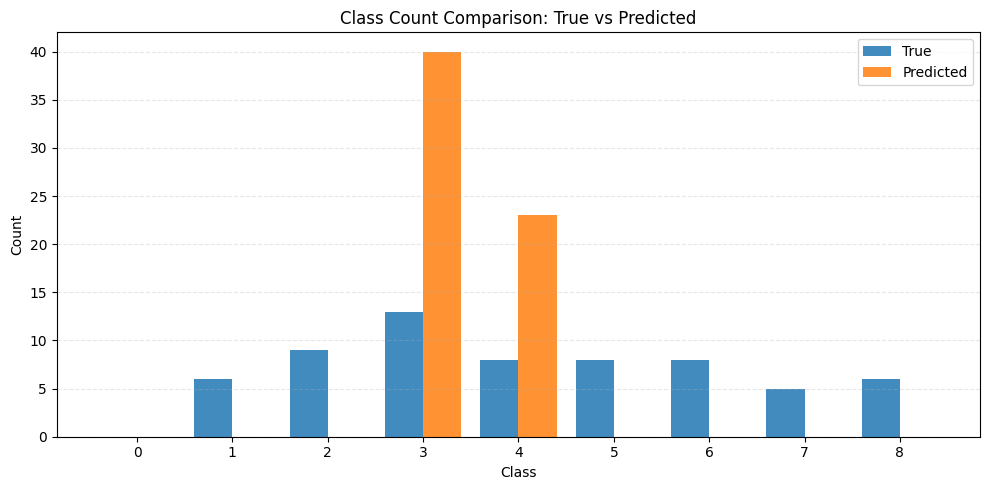

In [156]:
import numpy as np
import matplotlib.pyplot as plt

# If all_y/all_pred already exist from previous cell, this will use them.
# Otherwise, you can paste the arrays manually.
true_counts = np.bincount(all_y, minlength=9)
pred_counts = np.bincount(all_pred, minlength=9)

classes = np.arange(len(true_counts))
width = 0.4

plt.figure(figsize=(10, 5))
plt.bar(classes - width/2, true_counts, width=width, label="True", alpha=0.85)
plt.bar(classes + width/2, pred_counts, width=width, label="Predicted", alpha=0.85)

plt.xticks(classes, [str(c) for c in classes])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Count Comparison: True vs Predicted")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Running Other Tasks

To run a different task, modify the `TASK_NAME` variable in cell 4 (configurations) to one of:
- `'graph_classification'` (default): Predict frequency bin from graph structure
- `'triangle_classification'`: Classify topological role of triangles (9 embedding × weight classes)
- `'triangle_common_neighbors'`: Predict number of common neighbors for each triangle

Then re-run the configuration cell and subsequent cells. The dataset will automatically load the appropriate task variant, and the model will be configured with the correct number of output classes (9 for all tasks).

### Task Details:

**Task 1: Graph-level Classification**
- Input: Graph structure with node features (mean correlation, std correlation, noise diagonal)
- Output: Frequency bin (0-8) representing the best frequency
- Level: Graph-level prediction

**Task 2: Triangle Classification**
- Input: Topological features of triangles (3 edge weights from correlation matrix)
- Output: Triangle role classification (9 classes based on embedding × weight):
  - Embedding classes: Core (many common neighbors), Bridge (some), Isolated (few)
  - Weight classes: Strong (high correlation), Medium, Weak (low correlation)
- Level: Triangle (motif) level prediction

**Task 3: Triangle Common-Neighbors**
- Input: Triangle node degrees (structural features)
- Output: Number of common neighbors (0-8, mapping neighbors count to class)
- Level: Triangle (motif) level prediction